In [1]:
import os
import pandas as pd
import polars as pl 
from dotenv import load_dotenv
from pymongo import MongoClient 
import missingno as msno
import glob

1. Chargement et instance du dataset

In [2]:
load_dotenv()
uri = os.getenv("MONGO_URI")
client = MongoClient(uri)
client.admin. command('ping')

{'ok': 1.0}

In [3]:
files = glob.glob("../data/listings*.csv")

for path in files:
    city = path.split("listings")[0].split(".")[1]
    dfv0 = pl.read_csv(path)
    dfv0 = dfv0.with_columns(pl.lit(city).alias("city"))

2. Mapping

In [4]:
TYPE_MAPPING = {
    "Int64": [
        "id",
        "scrape_id",
        "host_id",
        "accommodates",
        "minimum_nights",
        "maximum_nights",
        "minimum_minimum_nights",
        "maximum_minimum_nights",
        "minimum_maximum_nights",
        "maximum_maximum_nights",
        "availability_30",
        "availability_60",
        "availability_90",
        "availability_365",
        "number_of_reviews",
        "number_of_reviews_ltm",
        "number_of_reviews_l30d",
        "calculated_host_listings_count",
        "calculated_host_listings_count_entire_homes",
        "calculated_host_listings_count_private_rooms",
        "calculated_host_listings_count_shared_rooms",
        "bedrooms",
        "beds",
        "host_listings_count",
        "host_total_listings_count",
    ],
    "Float64Specific": [
        "price",
        "host_response_rate",
        "host_acceptance_rate", 
    ],
    "Float64": [
        "latitude",
        "longitude",
        "minimum_nights_avg_ntm",
        "maximum_nights_avg_ntm",
        "bathrooms",
        "reviews_per_month",
        "review_scores_rating",
        "review_scores_accuracy",
        "review_scores_cleanliness",
        "review_scores_checkin",
        "review_scores_communication",
        "review_scores_location",
        "review_scores_value",
    ],
    "Boolean": [
        "host_is_superhost",
        "host_has_profile_pic",
        "host_identity_verified",
        "has_availability",
        "instant_bookable",
    ],
    "Date": [
        "last_scraped",
        "host_since",
        "calendar_last_scraped",
        "first_review",
        "last_review",
    ],
    "String": [
        "listing_url",
        "source",
        "name",
        "description",
        "neighborhood_overview",
        "picture_url",
        "host_url",
        "host_name",
        "host_location",
        "host_about",
        "host_response_time",
        "host_thumbnail_url",
        "host_picture_url",
        "host_neighbourhood", 
        "neighbourhood",
        "neighbourhood_cleansed",
        "property_type",
        "room_type",
        "bathrooms_text",
        "license",
    ],
    "List": [
        "amenities",
        "host_verifications",
    ]
}

FIELD_MAPPING = {
    "availability": [
        "availability_30",
        "availability_60",
        "availability_90",
        "availability_365",
        "has_availability",
        "instant_bookable",
    ],
    "host": [
        "calculated_host_listings_count",
        "calculated_host_listings_count_entire_homes",
        "calculated_host_listings_count_private_rooms",
        "calculated_host_listings_count_shared_rooms",
        "host_about",
        "host_acceptance_rate",
        "host_has_profile_pic",
        "host_id",
        "host_identity_verified",
        "host_is_superhost",
        "host_listings_count",
        "host_location",
        "host_name",
        "host_neighbourhood",
        "host_picture_url",
        "host_response_rate",
        "host_response_time",
        "host_since",
        "host_thumbnail_url",
        "host_total_listings_count",
        "host_url",
        "host_verifications",
    ],
    "location": [
        "latitude",
        "longitude",
        "neighbourhood",
        "neighbourhood_cleansed",
        "neighborhood_overview",
    ],
    "night": [
        "maximum_maximum_nights",
        "maximum_minimum_nights",
        "maximum_nights",
        "maximum_nights_avg_ntm",
        "minimum_maximum_nights",
        "minimum_minimum_nights",
        "minimum_nights",
        "minimum_nights_avg_ntm",
    ],
    "property": [
        "accommodates",
        "amenities",
        "bathrooms",
        "bathrooms_text",
        "bedrooms",
        "beds",
        "property_type",
        "room_type",
    ],
    "review": [
        "first_review",
        "last_review",
        "number_of_reviews",
        "number_of_reviews_l30d",
        "number_of_reviews_ltm",
        "review_scores_accuracy",
        "review_scores_checkin",
        "review_scores_cleanliness",
        "review_scores_communication",
        "review_scores_location",
        "review_scores_rating",
        "review_scores_value",
        "reviews_per_month",
    ],
    "scraping": [
        "calendar_last_scraped",
        "last_scraped",
        "scrape_id",
        "source",
    ],
    "root": [
        "id",
        "city",
        "description",
        "license",
        "listing_url",
        "name",
        "picture_url",
        "price",
    ],
}

3. Nettoyage NAN, duplcates, col

<Axes: >

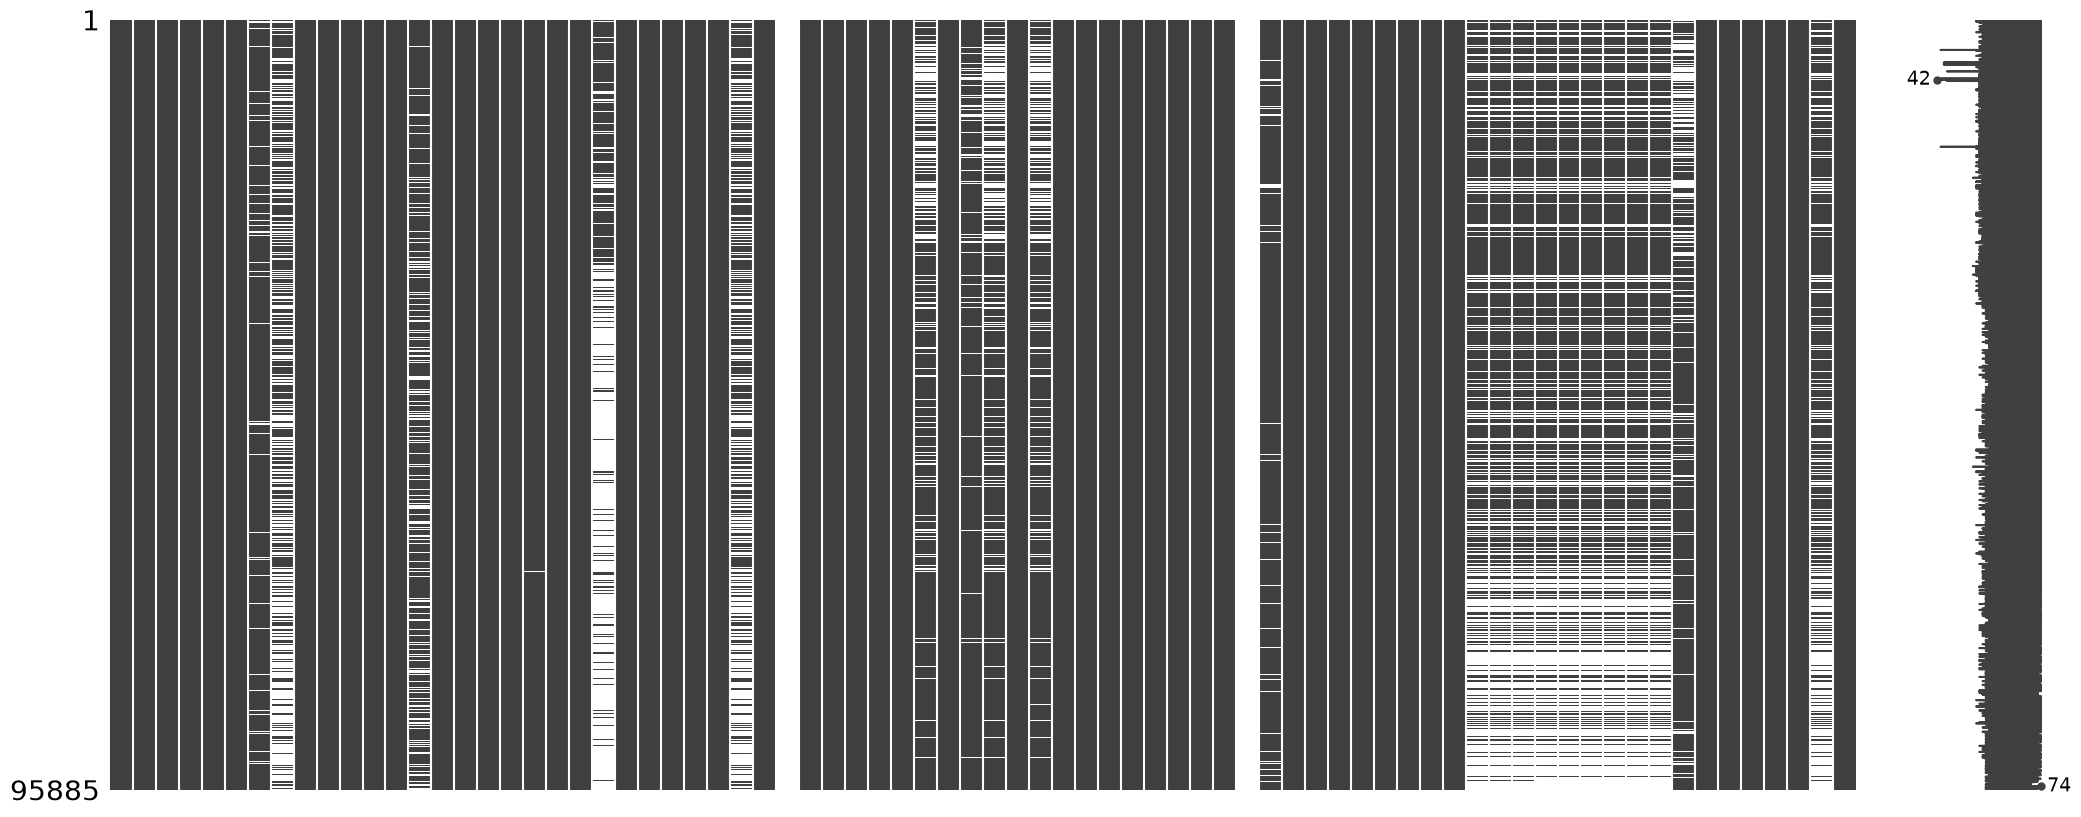

In [5]:
# Base actuelle
msno.matrix(dfv0.to_pandas())

<Axes: >

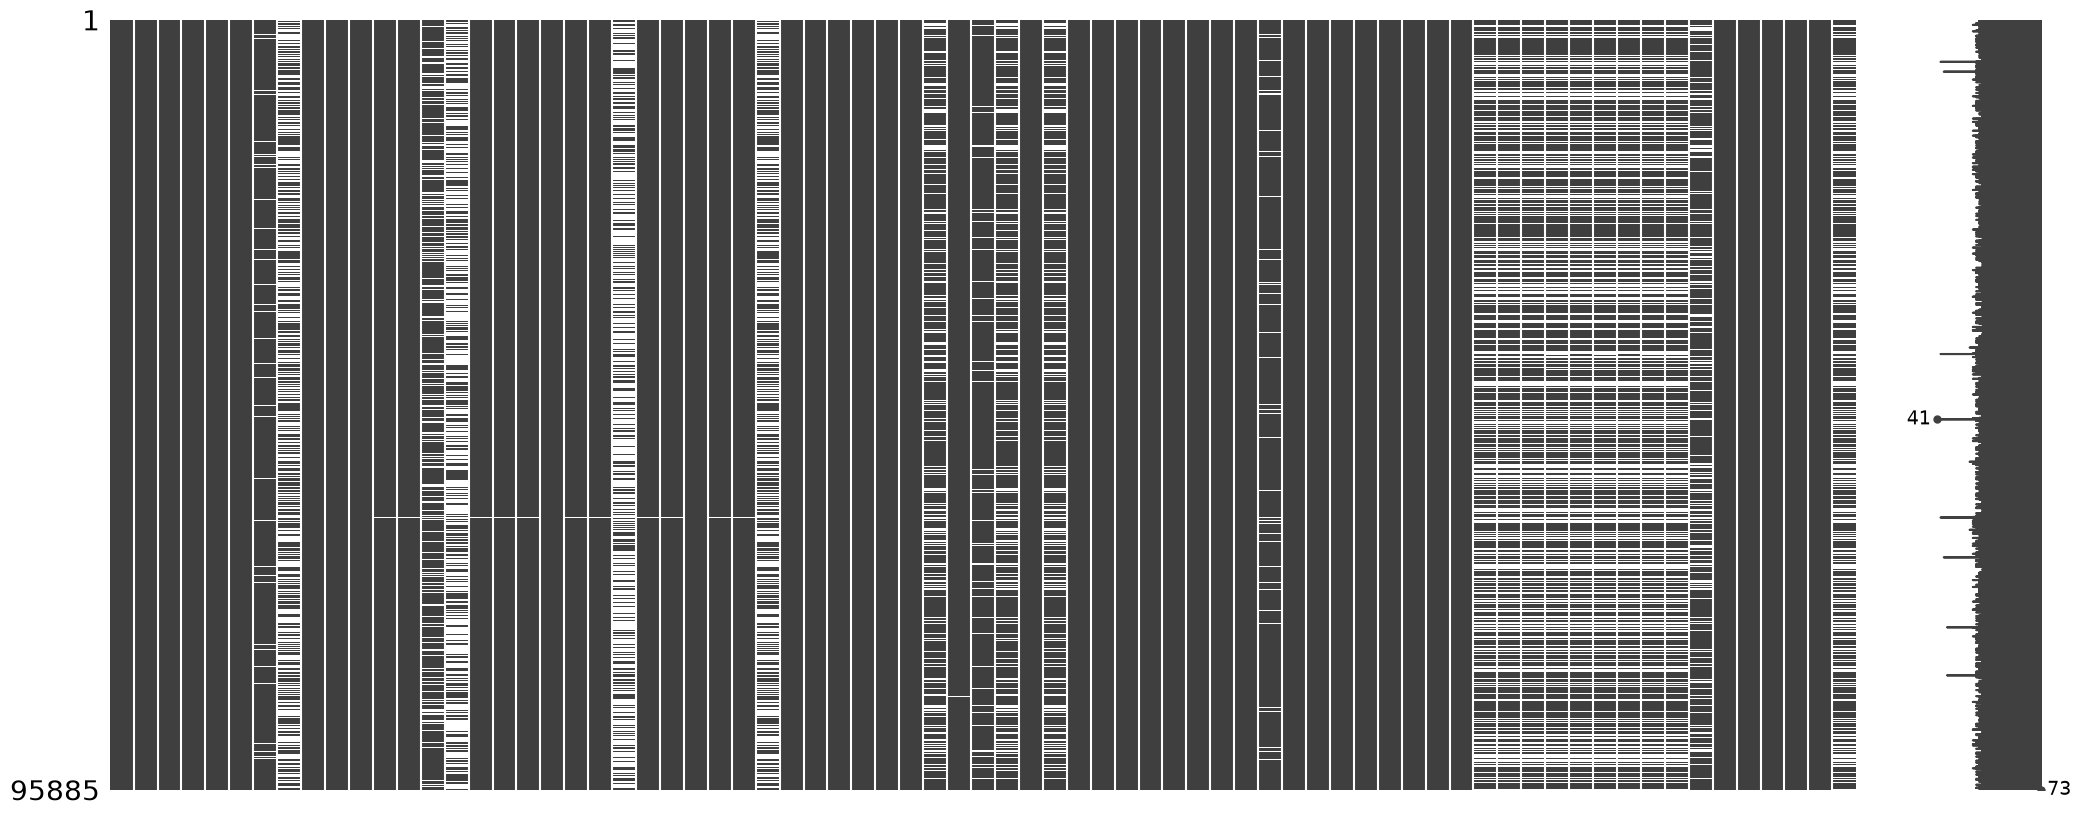

In [6]:
def clean(dfv0:pl.DataFrame):
    dfv0 = dfv0.with_columns(
    pl.col(pl.String).str.strip_chars().replace("", None)
    )
    dfv0 = dfv0.unique(subset=["id"])
    empty_col = [c for c in dfv0.columns if dfv0[c].null_count() / dfv0.height > 0.99]
    dfv0 = dfv0.drop(empty_col)
    return dfv0

dfv1 = clean(dfv0)

# Base nettoyée
msno.matrix(dfv1.to_pandas())

4. Casting

In [7]:
def cast(dfv1:pl.DataFrame):
    dfv1 = dfv1.with_columns(
        *[pl.col(c).str.replace_all(r"[$,%]", "").cast(pl.Float64, strict=False) for c in TYPE_MAPPING["Float64Specific"]],
        *[pl.col(c).cast(pl.Int64, strict=False) for c in TYPE_MAPPING["Int64"]],
        *[pl.col(c).cast(pl.Float64, strict=False) for c in TYPE_MAPPING["Float64"]],
        *[pl.col(c).str.to_datetime() for c in TYPE_MAPPING["Date"]], 
        *[(pl.col(c) == "t").alias(c) for c in TYPE_MAPPING["Boolean"]],
        pl.col("host_verifications").str.replace_all("'", '"').str.replace_all("None", "null").str.json_decode(dtype=pl.List(pl.String)),
        pl.col("amenities").str.json_decode(dtype=pl.List(pl.String)),
    )
    return dfv1

dfv2 = cast(dfv1)

dfv2.head(1)

id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
i64,str,i64,datetime[μs],str,str,str,str,str,i64,str,str,datetime[μs],str,str,str,f64,f64,bool,str,str,str,i64,i64,list[str],bool,bool,str,str,f64,f64,str,str,i64,f64,str,i64,i64,list[str],f64,i64,i64,i64,i64,i64,i64,f64,f64,bool,i64,i64,i64,i64,datetime[μs],i64,i64,i64,datetime[μs],datetime[μs],f64,f64,f64,f64,f64,f64,f64,str,bool,i64,i64,i64,i64,f64
40154806,"""https://www.airbnb.com/rooms/4…",20240610195007,2024-06-11 00:00:00,"""city scrape""","""29:4⃣️Room familiale chambre h…","""84 Bd Massena Tour Bologna bui…","""Cartier bank la Poste, shop ca…","""https://a0.muscache.com/pictur…",60526741,"""https://www.airbnb.com/users/s…","""Annie""",2016-02-26 00:00:00,"""Paris, France""","""75 Paris , appartement entier …","""within an hour""",100.0,100.0,false,"""https://a0.muscache.com/im/pic…","""https://a0.muscache.com/im/pic…","""Place d'Italie - Quartier Chin…",7,12,"[""email"", ""phone""]",true,true,"""Neighborhood highlights""","""Gobelins""",48.82399,2.36645,"""Private room in condo""","""Private room""",2,1.0,"""1 shared bath""",1,2,"[""Extra pillows and blankets"", ""Dining table"", … ""Freezer""]",96.0,1,1125,1,1,1125,1125,1.0,1125.0,true,15,20,48,323,2024-06-11 00:00:00,31,6,0,2021-06-30 00:00:00,2024-03-21 00:00:00,4.52,4.58,4.26,4.65,4.58,4.48,4.55,null,true,6,1,5,0,0.86


5.Reshape

In [8]:
def reshape(dfv2:pl.DataFrame):
    MAPPING = {name:[c for c in cols if c in dfv2.columns] for name, cols in FIELD_MAPPING.items()}
    dfv2 = dfv2.with_columns(*[pl.struct(cols).alias(name) for name, cols in MAPPING.items() if name != "root"])
    dfv2 = dfv2.drop(*[c for name, cols in MAPPING.items() if name != "root" for c in cols])
    return dfv2

dfv3 = reshape(dfv2)

dfv3.columns

['id',
 'listing_url',
 'name',
 'description',
 'picture_url',
 'price',
 'license',
 'availability',
 'host',
 'location',
 'night',
 'property',
 'review',
 'scraping']

In [9]:
# check
print(f"Origine: {[c for c in dfv0.columns if c.startswith("neigh")]}")
print(f"Après clean: {[c for c in dfv1.columns if c.startswith("neigh")]}")
print(f"Après casting: {[c for c in dfv2.columns if c.startswith("neigh")]}")
print(f"Après reshape: {[c for c in dfv3.columns if c.startswith("neigh")]}")

Origine: ['neighborhood_overview', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed']
Après clean: ['neighborhood_overview', 'neighbourhood', 'neighbourhood_cleansed']
Après casting: ['neighborhood_overview', 'neighbourhood', 'neighbourhood_cleansed']
Après reshape: []


In [10]:
# test
dfv3.select("location").head(3)

location
struct[5]
"{48.82399,2.36645,""Neighborhood highlights"",""Gobelins"",""Cartier bank la Poste, shop caterer baker restaurant cafe bars tabac marc do, supermarket casino and Asian Asian business practical and safety""}"
"{48.831177,2.337718,""Neighborhood highlights"",""Observatoire"",""very well located, extremely safe neighborhood, a 6-minute walk to Denfert Rochereau (RER access, l.4,6) and 4' from Saint Jacques (l.6). Very well served by buses (64, 62, 21) .<br />vélib stop 1'from the house.<br />Super Franprix market 2'away, and Carrefour, open every day.<br />Numerous cafes , shops, restaurants nearby.<br />Gym (sauna) opposite the house: Cercles de la forme open from Monday to Friday from 7 a.m. to 10 p.m. and on weekends:9 a.m. to 7 p.m. Daily rate: 20€, weekly: 45€""}"
"{48.834124,2.3221263,null,""Observatoire"",null}"


6.Chargement

In [11]:
def load(dfv3, client):
    db = client["airbnb"]
    collection = db["listings"]
    collection.drop()
    docs = dfv3.to_dicts()
    collection.insert_many(docs)
    return collection.count_documents({})

load(dfv3, client)

95885